In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
# Set plot style for clean visuals
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

In [ ]:
df = pd.read_csv('medical_costs.csv')

In [ ]:
df.head()

,Age,Sex,BMI,Children,Smoker,Region,Medical Cost
0,58,male,15.6,2,yes,northwest,17907.54
1,24,male,29.8,0,yes,northeast,16312.64
2,50,male,29.0,5,no,northwest,6819.21
3,35,male,34.0,1,no,southeast,5247.87
4,31,female,17.6,3,yes,southeast,17525.49


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Age           10000 non-null  int64  
 1   Sex           10000 non-null  str    
 2   BMI           10000 non-null  float64
 3   Children      10000 non-null  int64  
 4   Smoker        10000 non-null  str    
 5   Region        10000 non-null  str    
 6   Medical Cost  10000 non-null  float64
dtypes: float64(2), int64(2), str(3)
memory usage: 547.0 KB


In [ ]:
print(f"\nDataset Dimensions: {df.shape[0]} rows,{df.shape[1]} columns\n")


Dataset Dimensions: 10000 rows,7 columns



## DATA PREPROCESSING

In [ ]:
# Handling Missing Values
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Age             0
Sex             0
BMI             0
Children        0
Smoker          0
Region          0
Medical Cost    0
dtype: int64


In [ ]:
# Encoding Categorical Variables
# Binary encoding for binary categories
df['Sex_encoded'] = df['Sex'].map({'male': 1,'female': 0})
df['Smoker_encoded'] = df['Smoker'].map({'yes': 1,'no': 0})

In [ ]:
# One-Hot Encoding for the 'Region' column
df = pd.get_dummies(df, columns=['Region'],drop_first=False)

In [ ]:
# Train-Test Split
X = df.drop(columns=['Medical Cost','Sex','Smoker']) # Features
y = df['Medical Cost']

In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
# Feature Scaling
scaler = StandardScaler()
numerical_cols = ['Age','BMI','Children']

In [ ]:
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

In [ ]:
X_train_scaled[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test_scaled[numerical_cols] = scaler.transform(X_test[numerical_cols])

In [ ]:
print("\nPreprocessing complete. Training shapes:", X_train_scaled.shape,y_train.shape)


Preprocessing complete. Training shapes: (8000, 9) (8000,)


##  EXPLORATORY DATA ANALYSIS (EDA) VISUALIZATIONS

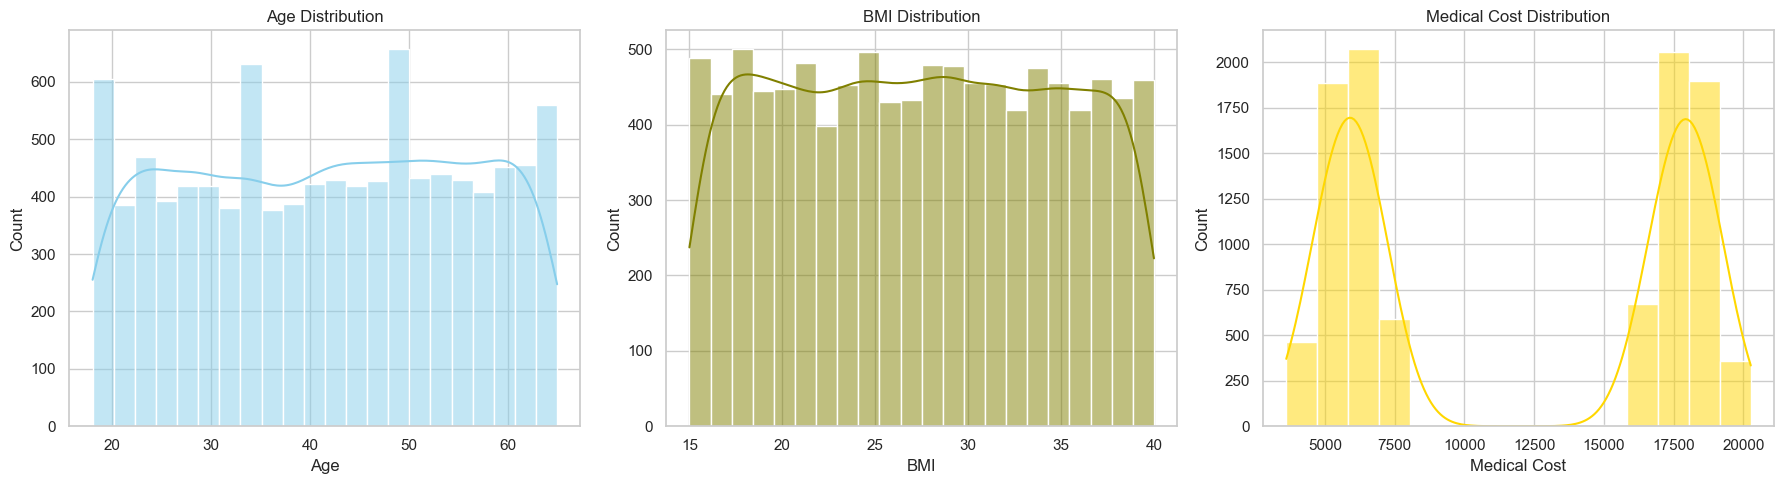

In [ ]:
# Plot 1: Histograms of Continuous Variables
fig, axes = plt.subplots(1,3,figsize=(18,5))
sns.histplot(df['Age'],kde=True,ax=axes[0],color='skyblue').set_title('Age Distribution')
sns.histplot(df['BMI'],kde=True,ax=axes[1],color='olive').set_title('BMI Distribution')
sns.histplot(df['Medical Cost'],kde=True,ax=axes[2],color='gold').set_title('Medical Cost Distribution')
plt.tight_layout()
plt.show()

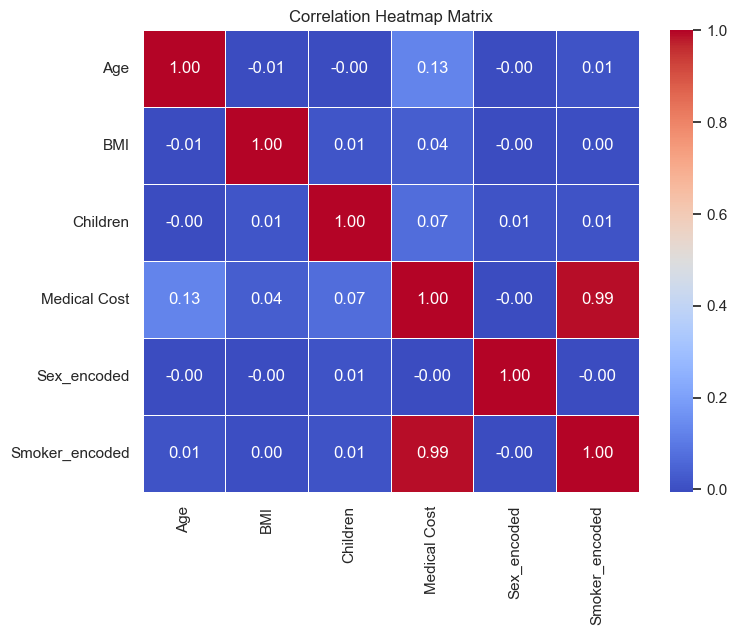

In [ ]:
# Plot 2: Correlation Heatmap
plt.figure(figsize=(8,6))
# Select only numeric values for correlation
numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(),annot=True,cmap='coolwarm',fmt=".2f",linewidths=0.5)
plt.title('Correlation Heatmap Matrix')
plt.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_1816\3818375122.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Smoker',y='Medical Cost',data=df,ax=axes[0],palette='Set2').set_title('Medical Cost by Smoking Status')
C:\Users\Owner\AppData\Local\Temp\ipykernel_1816\3818375122.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Sex',y='Medical Cost', data=df,ax=axes[1],palette='Pastel1').set_title('Medical Cost by Gender')


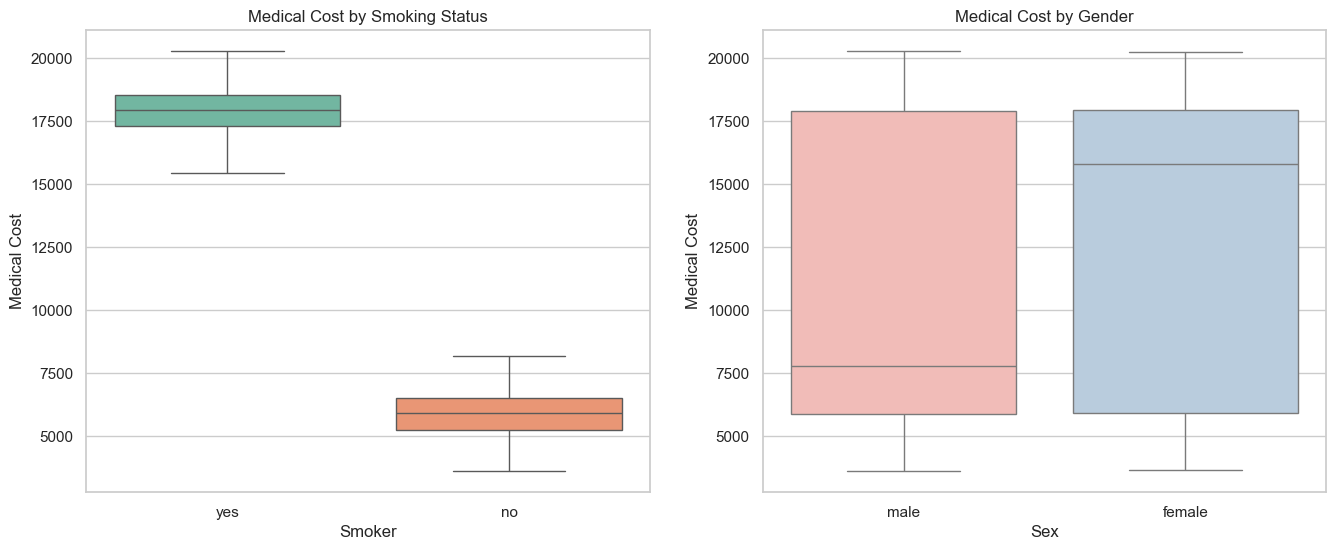

In [ ]:
# Plot 3: Boxplots (Impact of Lifestyle on Cost)
fig, axes = plt.subplots(1,2, figsize=(16, 6))
sns.boxplot(x='Smoker',y='Medical Cost',data=df,ax=axes[0],palette='Set2').set_title('Medical Cost by Smoking Status')
sns.boxplot(x='Sex',y='Medical Cost', data=df,ax=axes[1],palette='Pastel1').set_title('Medical Cost by Gender')
plt.show()

C:\Users\Owner\AppData\Local\Temp\ipykernel_1816\890511849.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sex',data=df,ax=axes[0],palette='viridis').set_title('Gender Distribution')
C:\Users\Owner\AppData\Local\Temp\ipykernel_1816\890511849.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Smoker',data=df,ax=axes[1], palette='magma').set_title('Smoker Count')
C:\Users\Owner\AppData\Local\Temp\ipykernel_1816\890511849.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Region',data=original_df,ax=axes[2], palette='cubehe

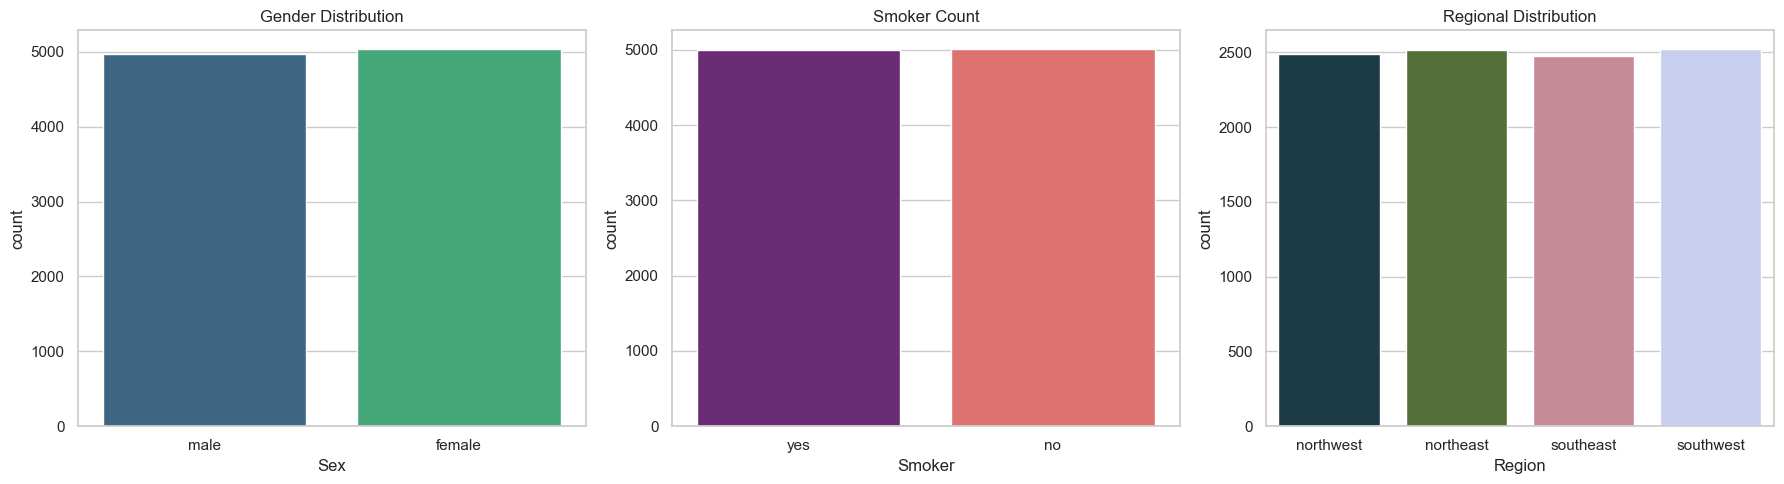

In [ ]:
# Plot 4: Class Distributions (Categorical Fields)
fig, axes = plt.subplots(1,3,figsize=(18,5))
sns.countplot(x='Sex',data=df,ax=axes[0],palette='viridis').set_title('Gender Distribution')
sns.countplot(x='Smoker',data=df,ax=axes[1], palette='magma').set_title('Smoker Count')
# Dynamic handling of region if it's already one-hot encoded in 'df' vs keeping original text
original_df = pd.read_csv('medical_costs.csv') # temporary pull for plotting original strings
sns.countplot(x='Region',data=original_df,ax=axes[2], palette='cubehelix').set_title('Regional Distribution')
plt.tight_layout()
plt.show()